## Demo notebook

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import sys

notebook_path = Path().absolute()
project_root = notebook_path.parent
sys.path.append(str(project_root))
from src.data_utils import SCGDataLoader

In [3]:
data_loader = SCGDataLoader()

In [4]:
data = data_loader.load_data()

In [5]:
%matplotlib inline

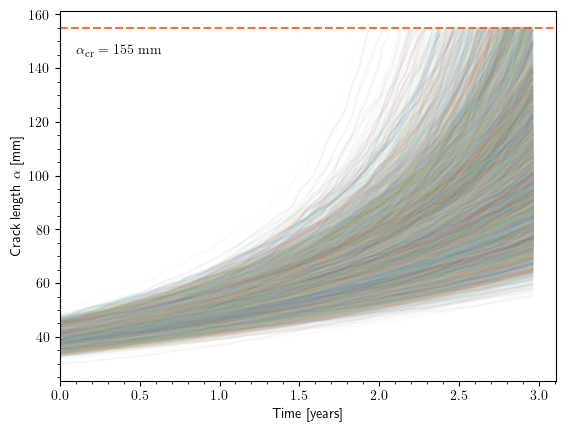

In [6]:
from src.visualisation import plot_scg_data

plot_scg_data(data["times"], data["crack_lengths"], save_fig_name="scg_data.pdf")

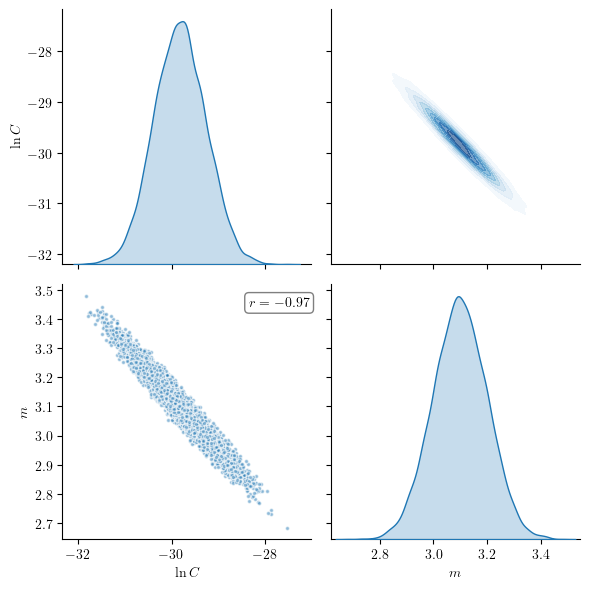

In [7]:
from src.visualisation import paris_params_pair_plot
paris_params_pair_plot(data["paris_c"], data["paris_m"], save_fig_name="paris_params_pair_plot.pdf")

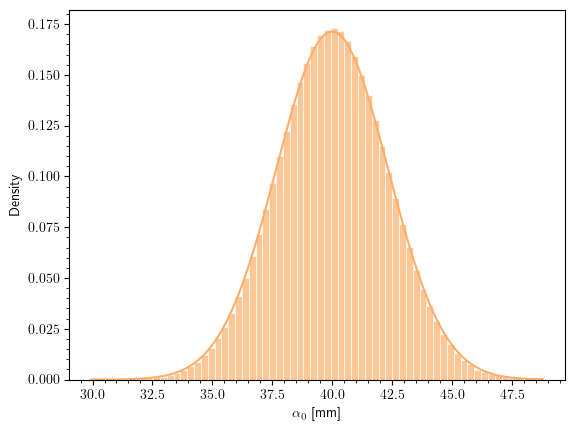

In [8]:
from src.visualisation import plot_initial_crack_length
plot_initial_crack_length(data["initial_crack_length"], save_fig_name="a0_hist.pdf")

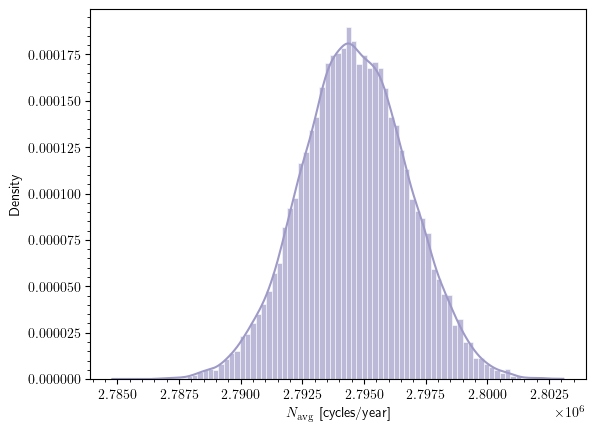

In [9]:
from src.visualisation import plot_avg_cycles
plot_avg_cycles(data["avg_cycles"], save_fig_name="avg_cycles_hist.pdf")

In [10]:
import numpy as np

print(f"Average equivalent number of cycles for an approx. 3-year span: {data['avg_cycles'].mean() * data['times'].max():.2f}")
print(f"Assuming an 8-second average period, this is approximately {data['avg_cycles'].mean() * data['times'].max() * 8 / 3600:.2f} hours of operation.")
print(f"Or approximately {data['avg_cycles'].mean() * data['times'].max() * 8 / 3600 / (365 * 24):.2f} years of operation.")

Average equivalent number of cycles for an approx. 3-year span: 8268437.54
Assuming an 8-second average period, this is approximately 18374.31 hours of operation.
Or approximately 2.10 years of operation.


In [11]:
print(f"""Based on the data, the average period is approximately:
{(3*365.25*24*60*60)/(data['avg_cycles'].mean() * data['times'].max()):.2f} seconds.""")

Based on the data, the average period is approximately:
11.45 seconds.


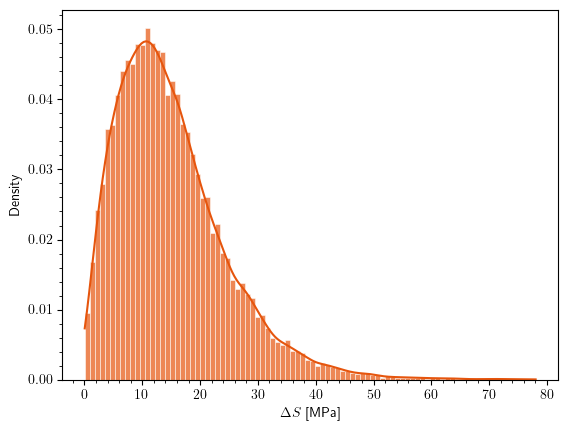

In [12]:
from src.visualisation import plot_stress_ranges
plot_stress_ranges(data["stress_ranges"], save_fig_name="stress_ranges_hist.pdf")

In [13]:
from src.visualisation import plot_paris_predictions
import numpy as np

In [14]:
# Randomly select instances to test the Paris law predictions
instances = np.random.randint(low=0, high=(data["times"].shape[0] - 1), size=10)
# Get the Paris law parameters for these instances
paris_params = (data["paris_c"][instances], data["paris_m"][instances])
# Get the initial crack lengths for these instances
initial_crack_lengths = data["initial_crack_length"][instances]
# Get the stress ranges for these instances
stress_ranges = np.linspace(10, 40, instances.shape[0])
# Use a common time array for all instances - using the first row of times
time_array = data["times"][0]
# Create array with the number of cycles for each instance
n_cycles = np.ones(instances.shape[0]) * np.mean(data["avg_cycles"][:, 0])

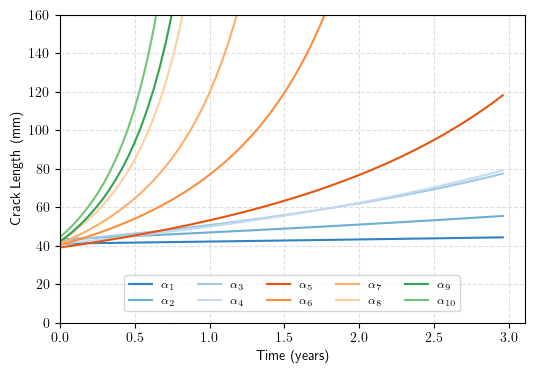

In [15]:
# Use our refactored function for plotting
fig, ax = plot_paris_predictions(
    paris_params=paris_params,
    ds=stress_ranges,
    navg=n_cycles,
    a0=initial_crack_lengths,
    times=time_array,
    save_fig_name="paris_predictions.pdf",
    figsize=(6, 4),
    plot_grid=True
)

# We can add additional customization if needed
#ax.set_title("Paris Law Crack Growth Predictions for Multiple Instances")

Parameters for instance 7082:
logC: -29.6175
m: 3.0327
ds: 23.3333
navg: 2793155.5950
a0: 39.0080


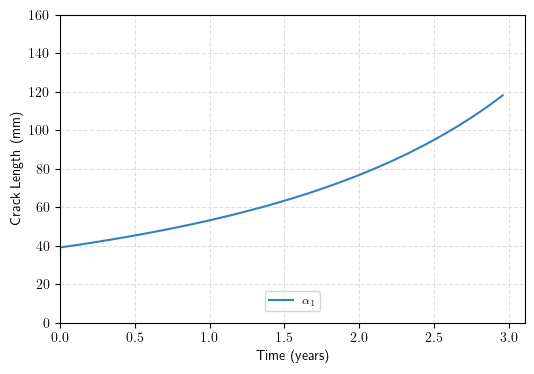

In [16]:
# Let's also test a single prediction to understand what's going on
inst = instances[4]
c = paris_params[0][4]
m = paris_params[1][4]
ds = stress_ranges[4]
navg = n_cycles[4]
a0 = initial_crack_lengths[4]

# Print these values to debug
print(f"Parameters for instance {inst}:")
print(f"logC: {np.log(c):.4f}")
print(f"m: {m:.4f}")
print(f"ds: {ds:.4f}")
print(f"navg: {navg:.4f}")
print(f"a0: {a0:.4f}")

# Plot a single instance prediction
fig, ax = plot_paris_predictions(
    paris_params=(c, m),
    ds=ds,
    navg=navg,
    a0=a0,
    times=time_array,
    figsize=(6, 4)
)

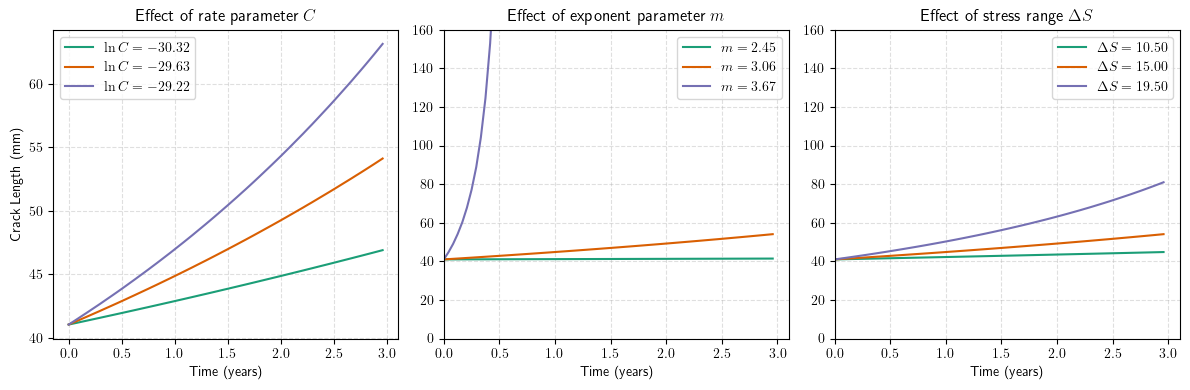

In [17]:
# Let's also explore how different parameters affect crack growth
from src.visualisation import plot_parameter_sensitivity

# Create baseline parameters
base_c = paris_params[0][0]
base_m = paris_params[1][0]
base_ds = 15.0
base_navg = n_cycles[0]
base_a0 = initial_crack_lengths[0]

# Use the new modular function for parameter sensitivity analysis
fig, axes = plot_parameter_sensitivity(
    base_c=base_c,
    base_m=base_m,
    base_ds=base_ds,
    base_navg=base_navg,
    base_a0=base_a0,
    times=time_array,
    save_fig_name="parameter_sensitivity.pdf",
)

# You can still customize the plot if needed
# axes[1].set_ylim(bottom=0, top=160)

## Testing Variable Stress Paris-Erdogan Model

This section demonstrates how to use the `VariableStressParisErdogan` model for simulating crack growth with time-varying stress ranges.

Average stress: 17.00 MPa
Stress range: 5.0 - 30.0 MPa


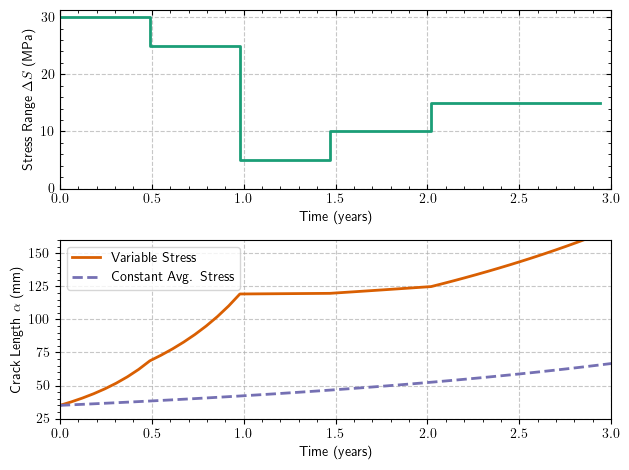

In [18]:
from src.visualisation import plot_variable_stress_comparison

# Define custom stress periods
stress_periods = [
    (0.0, 0.5, 30.0),
    (0.5, 1.0, 25.0),
    (1.0, 1.5, 5.0),
    (1.5, 2.0, 10.0),
    (2.0, 3.0, 15.0),
]

# Use the new visualization function
fig, axs = plot_variable_stress_comparison(
    stress_periods=stress_periods,
    logc=np.log(1e-13),
    m=3.2,
    navg=3e6,
    a0=35.0,
    cmap_name='Dark2',
    figsize=(6.4, 4.8),
    save_fig_name="variable_stress_comparison.pdf"
)

# Print some interesting statistics about the plot
print(f"Average stress: {np.mean([s[2] for s in stress_periods]):.2f} MPa")
print(f"Stress range: {min([s[2] for s in stress_periods]):.1f} - {max([s[2] for s in stress_periods]):.1f} MPa")

Final crack lengths with varying stress patterns:
Increasing  : 56.08 mm
Decreasing  : 56.09 mm
Cyclical    : 59.46 mm
Random      : 52.94 mm

Average stress for each pattern:
Increasing  : 15.00 MPa
Decreasing  : 15.00 MPa
Cyclical    : 15.00 MPa
Random      : 14.03 MPa


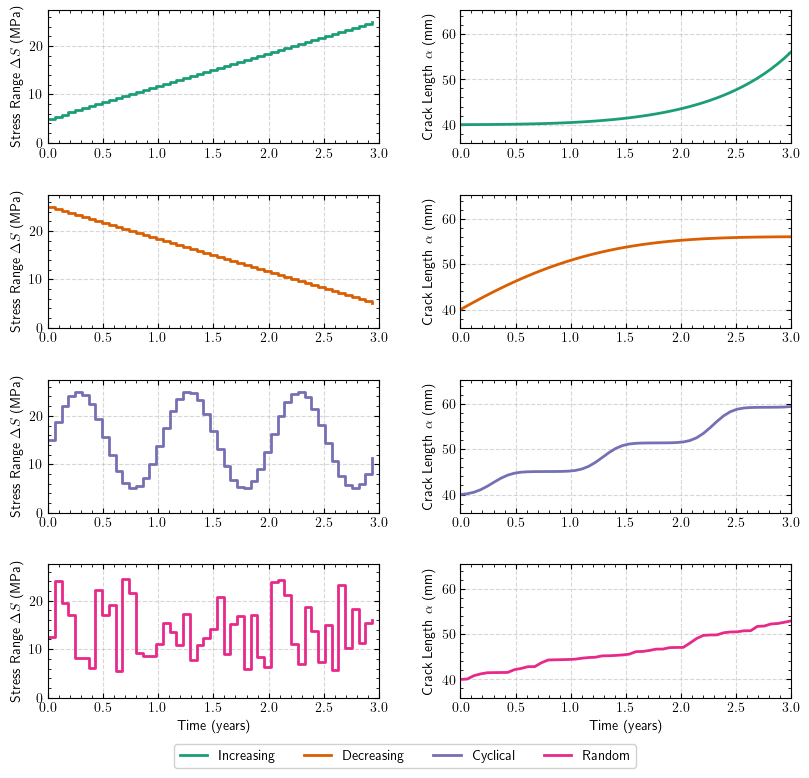

In [19]:
from src.visualisation import plot_stress_pattern_comparison

# Set parameters
logc = np.log(5e-14)  # Natural log of Paris law C parameter
m = 3.2               # Paris law exponent m
navg = 2.8e6          # Average cycles per year
a0 = 40.0             # Initial crack length (mm)

# Use the new function to create the comparison plot
fig, axes, stats = plot_stress_pattern_comparison(
    logc=logc,
    m=m,
    navg=navg,
    a0=a0,
    min_stress=5.0,
    max_stress=25.0,
    patterns=['increasing', 'decreasing', 'cyclical', 'random'],
    cmap_name='Dark2',
    figsize=(8.2, 8.2),
    save_fig_name="stress_pattern_comparison.pdf"
)

# Print analysis of the results
print("Final crack lengths with varying stress patterns:")
for pattern, length in stats['final_lengths'].items():
    print(f"{pattern.capitalize():<12}: {length:.2f} mm")

print("\nAverage stress for each pattern:")
for pattern, avg_stress in stats['avg_stresses'].items():
    print(f"{pattern.capitalize():<12}: {avg_stress:.2f} MPa")

# print("\nEffect of stress pattern (Length/Stress ratio):")
# for pattern, ratio in stats['length_stress_ratio'].items():
#     print(f"{pattern.capitalize():<12}: {ratio:.2f}")

# # Explanation of why patterns with same average stress produce different results
# print("\nObservation: Even with the same average stress, patterns produce")
# print(r"different final crack lengths because of the power law $(da/dN ∝ \Delta K^m)$.")
# print(f"When $m > 1$ (here m = {m:.1f}), high stress periods contribute")
# print("disproportionately more to crack growth than low stress periods.")
